<a href="https://colab.research.google.com/github/mel-oezkan/computer-vision-proj-lab/blob/main/beta-vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

import time
from tqdm import tqdm

from torchvision import transforms




In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.5MB/s]


In [3]:
class Encoder(nn.Module):

    def __init__(self, img_channel=1, n_latent=10):
        super(Encoder, self).__init__()

        self.img_channel = img_channel
        self.c1 = self._conv_block(self.img_channel, 64)
        self.c2 = self._conv_block(64, 128)
        self.c3 = self._conv_block(128, 128)

        self.pool = nn.MaxPool2d(2)
        self.mu = nn.Linear(128, n_latent)
        self.logvar = nn.Linear(128, n_latent)

    def _conv_block(self, in_channels, out_channels):
        """Helper to create a block of conv-batchnorm-relu layers"""
        # Use stride=2 on the last conv if stride_last is True
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            # nn.MaxPool2d(2),
            nn.Dropout(.25)
        )

    def forward(self, x):
        x = self.c1(x)#; print(x.shape)
        x = self.c2(x)#; print(x.shape)
        x = self.c3(x)#; print(x.shape)

        x = self.pool(x)#; print(x.shape)
        x = x.view(x.size(0), -1)

        mu = self.mu(x)
        logvar = self.logvar(x)

        return mu, logvar

    @staticmethod
    def reparemeterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.rand_like(std)
        z = mu + eps * std
        return z

In [4]:
e = Encoder()
for im, _ in test_data:
    mu, logvar = e(im.unsqueeze(0))
    break

In [5]:
class Decoder(nn.Module):

    def __init__(self, img_channel=1, n_latent=10):
        super(Decoder, self).__init__()

        self.img_channel = img_channel
        self.n_latent = n_latent

        self.projection = nn.Linear(n_latent, 7*7*n_latent)
        self.c1 = self._trans_conv_block(n_latent, 64, padding=1)
        self.c2 = self._trans_conv_block(64, 128, padding=1)
        self.c3 = self._trans_conv_block(128, 128, padding=1, stride=1)
        self.c4 = nn.ConvTranspose2d(128, self.img_channel, kernel_size=4, stride=1, padding=0)

    def _trans_conv_block(self, in_channels, out_channels, stride=2, padding=1):
        """Helper to create a block of conv-batchnorm-relu layers"""
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=padding),
            nn.ReLU(),
        )

    def forward(self, x):
        x = self.projection(x)
        x = x.view(x.size(0), self.n_latent, 7, 7)
        x = self.c1(x)  # 7x7 -> 13x13
        x = self.c2(x)  # 13x13 -> 25x25
        x = self.c3(x)  # 25x25 -> 25x25
        x = self.c4(x)  # 25x25 -> 28x28
        return x



In [6]:
e = Encoder()
d = Decoder()

for im, _ in test_data:
    print(im.shape)
    mu, logvar = e(im.unsqueeze(0))
    z = Encoder.reparemeterize(mu, logvar)

    print("decode shape")
    print(d(z).shape)
    break

torch.Size([1, 28, 28])
decode shape
torch.Size([1, 1, 28, 28])


In [7]:
class VAE(nn.Module):
    def __init__(
        self,
        img_channel=1,
        n_latent=10,
    ):
        super(VAE, self).__init__()

        self.img_channel = img_channel
        self.n_latent = n_latent

        self.enc = Encoder(img_channel, n_latent)
        self.dec = Decoder(img_channel, n_latent)

    def reparemeterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.rand_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparemeterize(mu, logvar)
        x_recon = self.dec(z)

        return x_recon, mu, logvar

    def kl_loss(sefl, mu, logvar):
        """Compute the KL divergence loss"""
        return -.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    def reconstruction_loss(self, x_recon, x_true):
        """Compute reconstruction loss (MSE)"""
        return nn.functional.mse_loss(x_recon, x_true, reduction="sum")

    def loss(self, x):
        """Compute total VAE loss"""
        x_recon, mu, logvar = self.forward(x)
        kl_div = self.kl_loss(mu, logvar)
        recon_loss = self.reconstruction_loss(x_recon, x)
        return recon_loss + kl_div, recon_loss, kl_div



In [11]:
# Create data loaders
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(img_channel=1, n_latent=32).to(device)  # Use VAE instead of Encoder

# Add torch.compile() for optimization
if torch.__version__ >= "2.0.0":
    model = torch.compile(model)
    print("Model compiled with torch.compile()")
else:
    print("torch.compile() not available in this PyTorch version")

# Use Adam optimizer for VAE (no criterion needed as loss is built into VAE)
optimizer = optim.Adam(model.parameters(), lr=0.001)

Model compiled with torch.compile()


In [12]:

def visualize_reconstructions(model, data_loader, device, epoch, num_images=8):
    """Visualize original vs reconstructed images"""
    model.eval()
    with torch.no_grad():
        # Get a batch of data
        data_iter = iter(data_loader)
        data, _ = next(data_iter)
        data = data[:num_images].to(device)

        # Get reconstructions
        x_recon, _, _ = model(data)

        # Move to CPU for plotting
        data = data.cpu()
        x_recon = x_recon.cpu()

        # Create figure
        fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
        fig.suptitle(f'Reconstructions at Epoch {epoch+1}', fontsize=16)

        for i in range(num_images):
            # Original images (top row)
            axes[0, i].imshow(data[i].squeeze(), cmap='gray')
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')

            # Reconstructed images (bottom row)
            axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

Epoch  1/50 | Train: Total 2028.6623, Recon 1790.5417, KL 238.1206 | Val: Total 1793.7903, Recon 1649.7965, KL 143.9938 | Time: 32.8s


Epoch  2/50 | Train: Total 1550.3575, Recon 1330.7995, KL 219.5580 | Val: Total 1474.3431, Recon 1335.4240, KL 138.9192 | Time: 54.3s


Epoch  3/50 | Train: Total 1456.8635, Recon 1241.3239, KL 215.5396 | Val: Total 1401.2899, Recon 1260.2362, KL 141.0537 | Time: 75.9s


Epoch  4/50 | Train: Total 1396.6673, Recon 1183.5118, KL 213.1555 | Val: Total 1329.5869, Recon 1191.8665, KL 137.7204 | Time: 97.8s



Visualizing reconstructions at epoch 5...


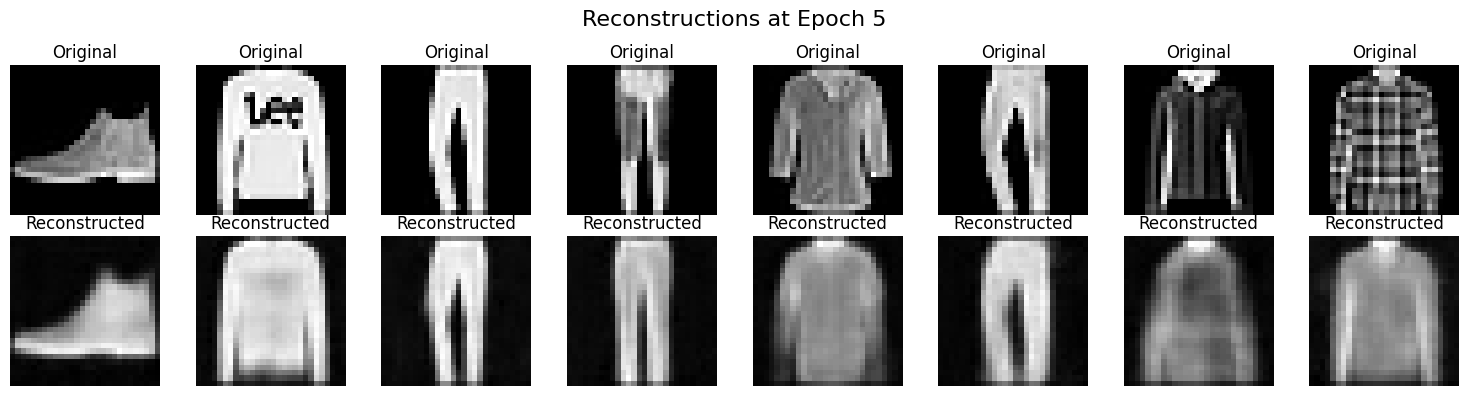

Epoch  5/50 | Train: Total 1357.4356, Recon 1146.4574, KL 210.9782 | Val: Total 1310.1512, Recon 1165.9275, KL 144.2236 | Time: 120.3s


Epoch  6/50 | Train: Total 1334.8911, Recon 1123.7811, KL 211.1100 | Val: Total 1282.0799, Recon 1142.8851, KL 139.1948 | Time: 141.9s


Epoch  7/50 | Train: Total 1310.4899, Recon 1100.9839, KL 209.5059 | Val: Total 1243.0028, Recon 1100.8296, KL 142.1732 | Time: 163.6s


Epoch  8/50 | Train: Total 1294.6047, Recon 1086.6446, KL 207.9601 | Val: Total 1291.0846, Recon 1149.4049, KL 141.6796 | Time: 185.5s


Epoch  9/50 | Train: Total 1276.9668, Recon 1069.7993, KL 207.1675 | Val: Total 1214.1632, Recon 1071.4643, KL 142.6989 | Time: 207.4s



Visualizing reconstructions at epoch 10...


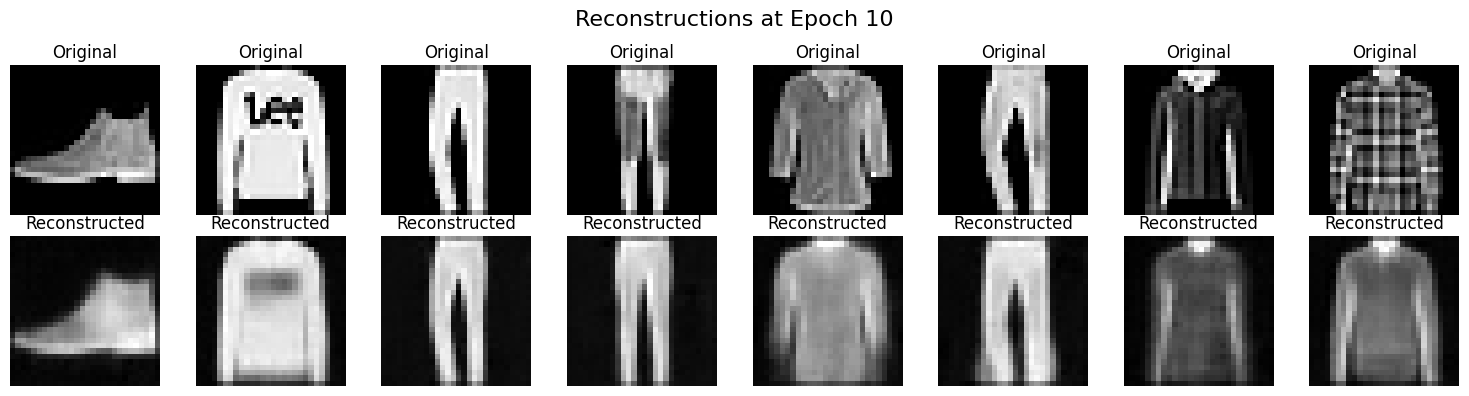

Epoch 10/50 | Train: Total 1265.8672, Recon 1058.9098, KL 206.9574 | Val: Total 1181.6552, Recon 1039.1128, KL 142.5424 | Time: 229.7s


Epoch 11/50 | Train: Total 1254.0929, Recon 1046.8142, KL 207.2786 | Val: Total 1208.7541, Recon 1068.9094, KL 139.8447 | Time: 251.7s


Epoch 12/50 | Train: Total 1247.2000, Recon 1040.4018, KL 206.7982 | Val: Total 1192.5558, Recon 1050.5953, KL 141.9605 | Time: 273.8s


Epoch 13/50 | Train: Total 1240.1475, Recon 1033.7320, KL 206.4155 | Val: Total 1213.0836, Recon 1072.5896, KL 140.4939 | Time: 295.7s


Epoch 14/50 | Train: Total 1233.1782, Recon 1026.8695, KL 206.3086 | Val: Total 1204.4778, Recon 1058.3760, KL 146.1018 | Time: 317.7s



Visualizing reconstructions at epoch 15...


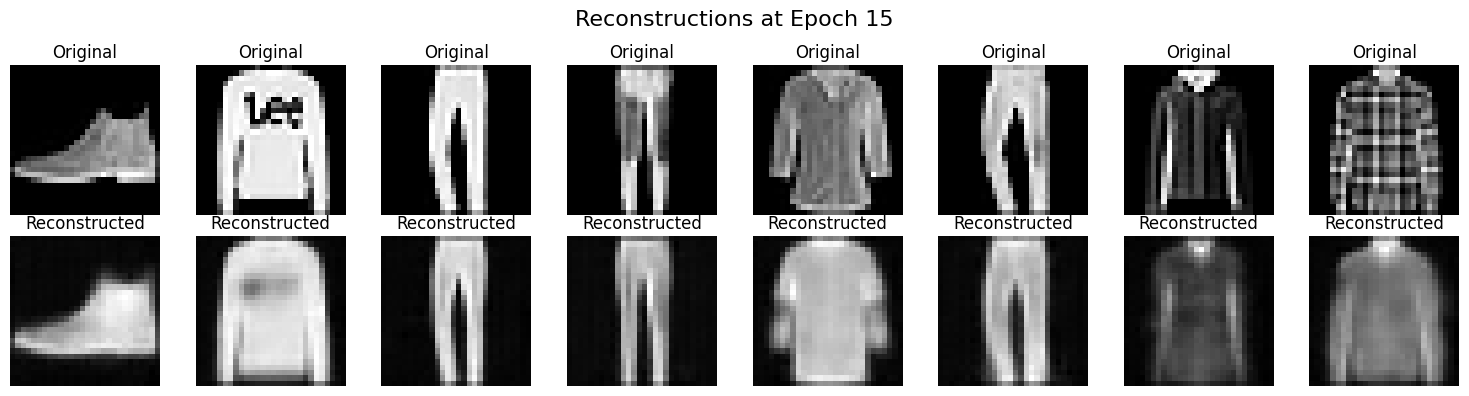

Epoch 15/50 | Train: Total 1226.6487, Recon 1020.7278, KL 205.9209 | Val: Total 1180.4611, Recon 1044.2054, KL 136.2557 | Time: 340.0s


Epoch 16/50 | Train: Total 1221.8341, Recon 1015.8158, KL 206.0183 | Val: Total 1177.8411, Recon 1035.6817, KL 142.1594 | Time: 362.2s


Epoch 17/50 | Train: Total 1212.5888, Recon 1006.7540, KL 205.8347 | Val: Total 1162.3013, Recon 1019.7185, KL 142.5828 | Time: 384.4s


Epoch 18/50 | Train: Total 1209.7266, Recon 1003.0432, KL 206.6834 | Val: Total 1161.6232, Recon 1019.4074, KL 142.2158 | Time: 406.6s


Epoch 19/50 | Train: Total 1204.8694, Recon 998.9660, KL 205.9033 | Val: Total 1151.4145, Recon 1010.8900, KL 140.5245 | Time: 429.0s



Visualizing reconstructions at epoch 20...


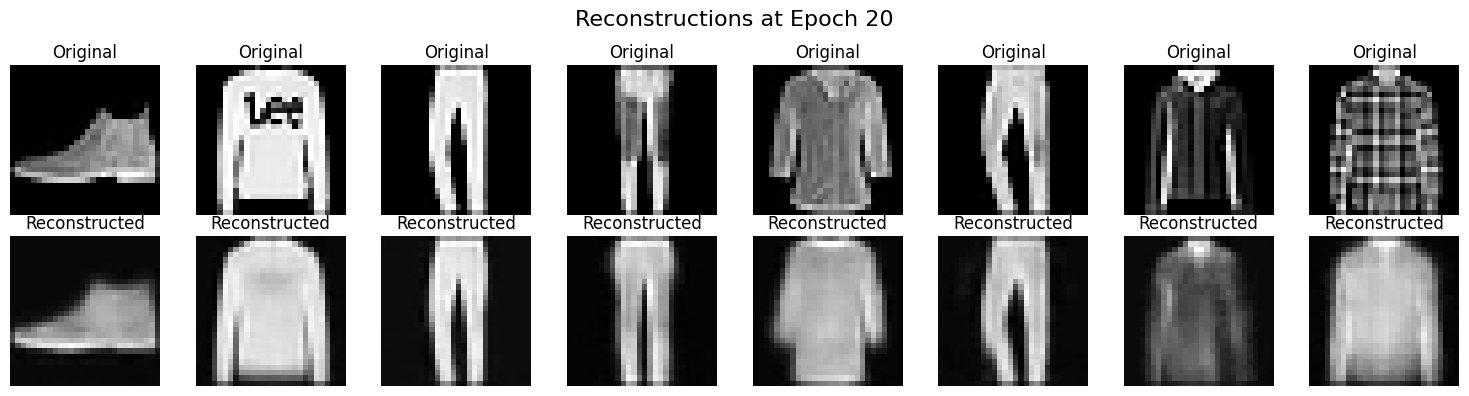

Epoch 20/50 | Train: Total 1202.9744, Recon 996.4988, KL 206.4756 | Val: Total 1188.2565, Recon 1045.9848, KL 142.2717 | Time: 451.8s


Epoch 21/50 | Train: Total 1197.3008, Recon 990.8373, KL 206.4636 | Val: Total 1158.6525, Recon 1019.5964, KL 139.0562 | Time: 474.4s


Epoch 22/50 | Train: Total 1193.4761, Recon 987.1320, KL 206.3440 | Val: Total 1148.8956, Recon 1009.1511, KL 139.7445 | Time: 497.1s


Epoch 23/50 | Train: Total 1189.6669, Recon 983.7524, KL 205.9145 | Val: Total 1130.8832, Recon 989.4293, KL 141.4539 | Time: 520.1s


Epoch 24/50 | Train: Total 1185.2576, Recon 979.6307, KL 205.6269 | Val: Total 1142.1290, Recon 1001.8369, KL 140.2921 | Time: 543.2s


Epoch 25/50 [Val]:   0%|          | 0/157 [00:00<?, ?it/s, Total=1077.9415, Recon=932.1880, KL=145.7535]

In [ ]:

# Training for 50 epochs with tqdm
num_epochs = 50
beta = 1.0
start_time = time.time()

history = {
    'train_total_loss': [],
    'train_recon_loss': [],
    'train_kl_loss': [],
    'val_total_loss': [],
    'val_recon_loss': [],
    'val_kl_loss': []
}

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_total_loss = 0.0
    running_recon_loss = 0.0
    running_kl_loss = 0.0

    # Training progress bar
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)

    for batch_idx, (data, target) in enumerate(train_pbar):
        data = data.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(data)

        # Calculate the VAE losses
        recon_loss = model.reconstruction_loss(x_recon, data)
        kl_loss = model.kl_loss(mu, logvar)
        total_vae_loss = recon_loss + beta * kl_loss

        total_vae_loss.backward()
        optimizer.step()

        # Accumulate batch losses
        running_total_loss += total_vae_loss.item()
        running_recon_loss += recon_loss.item()
        running_kl_loss += kl_loss.item()

        # Update progress bar with current metrics
        current_total_loss = running_total_loss / (batch_idx + 1)
        current_recon_loss = running_recon_loss / (batch_idx + 1)
        current_kl_loss = running_kl_loss / (batch_idx + 1)

        train_pbar.set_postfix({
            'Total': f'{current_total_loss:.4f}',
            'Recon': f'{current_recon_loss:.4f}',
            'KL': f'{current_kl_loss:.4f}'
        })

    # Validation phase
    model.eval()
    val_total_loss = 0.0
    val_recon_loss = 0.0
    val_kl_loss = 0.0

    # Validation progress bar
    val_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(val_pbar):
            data = data.to(device)
            x_recon, mu, logvar = model(data)

            # Calculate VAE losses for validation
            recon_loss = model.reconstruction_loss(x_recon, data)
            kl_loss = model.kl_loss(mu, logvar)
            total_loss = recon_loss + beta * kl_loss

            val_total_loss += total_loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()

            # Update validation progress bar
            current_val_total = val_total_loss / (batch_idx + 1)
            current_val_recon = val_recon_loss / (batch_idx + 1)
            current_val_kl = val_kl_loss / (batch_idx + 1)

            val_pbar.set_postfix({
                'Total': f'{current_val_total:.4f}',
                'Recon': f'{current_val_recon:.4f}',
                'KL': f'{current_val_kl:.4f}'
            })

    # Calculate final epoch metrics
    avg_train_total = running_total_loss / len(train_loader)
    avg_train_recon = running_recon_loss / len(train_loader)
    avg_train_kl = running_kl_loss / len(train_loader)

    avg_val_total = val_total_loss / len(test_loader)
    avg_val_recon = val_recon_loss / len(test_loader)
    avg_val_kl = val_kl_loss / len(test_loader)

    # Store metrics in history
    history['train_total_loss'].append(avg_train_total)
    history['train_recon_loss'].append(avg_train_recon)
    history['train_kl_loss'].append(avg_train_kl)
    history['val_total_loss'].append(avg_val_total)
    history['val_recon_loss'].append(avg_val_recon)
    history['val_kl_loss'].append(avg_val_kl)

    # Visualize reconstructions every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f'\nVisualizing reconstructions at epoch {epoch+1}...')
        visualize_reconstructions(model, test_loader, device, epoch)

    # Print epoch summary
    elapsed_time = time.time() - start_time
    print(f'Epoch {epoch+1:2d}/{num_epochs} | '
          f'Train: Total {avg_train_total:.4f}, Recon {avg_train_recon:.4f}, KL {avg_train_kl:.4f} | '
          f'Val: Total {avg_val_total:.4f}, Recon {avg_val_recon:.4f}, KL {avg_val_kl:.4f} | '
          f'Time: {elapsed_time:.1f}s')

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time:.1f} seconds!")
print(f"Final Validation Loss: {avg_val_total:.4f}")

In [ ]:

def plot_training_history(history):
    epochs = range(1, len(history['train_total_loss']) + 1)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Total loss
    ax1.plot(epochs, history['train_total_loss'], 'b-', label='Train')
    ax1.plot(epochs, history['val_total_loss'], 'r-', label='Validation')
    ax1.set_title('Total Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Reconstruction loss
    ax2.plot(epochs, history['train_recon_loss'], 'b-', label='Train')
    ax2.plot(epochs, history['val_recon_loss'], 'r-', label='Validation')
    ax2.set_title('Reconstruction Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    # KL loss
    ax3.plot(epochs, history['train_kl_loss'], 'b-', label='Train')
    ax3.plot(epochs, history['val_kl_loss'], 'r-', label='Validation')
    ax3.set_title('KL Divergence Loss')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# Plot after training
plot_training_history(history)